# Segmentación de clientes e-commerce

## Problemática y objetivo
Una empresa de e-commerce busca mejorar sus campañas de marketing, fidelización y retención de clientes. Actualmente, la base de usuarios contiene clientes con distintos patrones de gasto, frecuencia de visita, duración de sesión, número de transacciones y antigüedad; sin embargo, estas diferencias no están organizadas en perfiles accionables para negocio.

El problema central es que las campañas pueden terminar siendo genéricas: se envía la misma comunicación a clientes de alto gasto, clientes antiguos con baja actividad, visitantes frecuentes que no compran y usuarios recientes con potencial de retención. Esto reduce la eficiencia comercial, aumenta el riesgo de abandono y limita la personalización de ofertas.

El objetivo del proyecto es aplicar técnicas de segmentación no supervisada para identificar grupos de clientes con comportamientos similares y convertir esos grupos en acciones concretas de marketing, conversión, reactivación y fidelización.

In [1]:
# Librerías principales
import os
import warnings
warnings.filterwarnings("ignore")
os.environ.setdefault("LOKY_MAX_CPU_COUNT", "4")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.decomposition import PCA

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.figsize"] = (10, 5)

## 1. Carga del dataset

Se carga el archivo. La variable customer_id se usa solo como identificador y no debe entrar como variable de segmentacion, porque no representa comportamiento del cliente.

In [2]:
DATA_PATH = "ecommerce_customers.xlsx"

df = pd.read_excel(DATA_PATH)
df.head()

,customer_id,avg_monthly_spend,visit_frequency,avg_session_duration,num_transactions,customer_tenure,preferred_channel,country_region
0,1,359.61,11,7.32,3,58,Web,North America
1,2,283.41,11,9.10,6,35,Web,Latam
2,3,377.72,5,10.74,5,18,App,Europe
3,4,482.76,7,5.59,6,11,App,Latam
4,5,271.90,7,12.48,1,54,Web,Latam


In [3]:
print(f"Filas: {df.shape[0]:,}")
print(f"Columnas: {df.shape[1]:,}")
df.info()

Filas: 500
Columnas: 8
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   customer_id           500 non-null    int64  
 1   avg_monthly_spend     500 non-null    float64
 2   visit_frequency       500 non-null    int64  
 3   avg_session_duration  500 non-null    float64
 4   num_transactions      500 non-null    int64  
 5   customer_tenure       500 non-null    int64  
 6   preferred_channel     500 non-null    object 
 7   country_region        500 non-null    object 
dtypes: float64(2), int64(4), object(2)
memory usage: 31.4+ KB


## 2. Diccionario de variables

| Variable | Tipo esperado | Descripcion | Uso en segmentacion |
|---|---:|---|---|
| `customer_id` | Numerica identificadora | Identificador unico del cliente | No usar como feature |
| `avg_monthly_spend` | Numerica continua | Gasto promedio mensual | Si |
| `visit_frequency` | Numerica entera | Promedio de visitas al mes | Si |
| `avg_session_duration` | Numerica continua | Duracion promedio de sesion en minutos | Si |
| `num_transactions` | Numerica entera | Numero promedio de transacciones mensuales | Si |
| `customer_tenure` | Numerica continua/entera | Antigüedad del cliente en meses | Sí |
| `preferred_channel` | Categorica | Canal preferido de compra | Si, con encoding |
| `country_region` | Categorica | Region de procedencia | Si, con encoding |

In [4]:
# Normalización preventiva de nombres de columnas por si el archivo cambia de formato en futuras ejecuciones
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_", regex=False)
    .str.replace("__", "_", regex=False)
)

df.columns.tolist()

['customer_id',
 'avg_monthly_spend',
 'visit_frequency',
 'avg_session_duration',
 'num_transactions',
 'customer_tenure',
 'preferred_channel',
 'country_region']

## 3. Revision inicial de calidad de datos

Se revisan tipos de datos, valores faltantes, duplicados y unicidad del identificador.

In [5]:
resumen_calidad = pd.DataFrame({
    "tipo": df.dtypes.astype(str),
    "nulos": df.isna().sum(),
    "% nulos": (df.isna().mean() * 100).round(2),
    "valores_unicos": df.nunique()
})
resumen_calidad

,tipo,nulos,% nulos,valores_unicos
customer_id,int64,0,0.00,500
avg_monthly_spend,float64,0,0.00,493
visit_frequency,int64,0,0.00,19
avg_session_duration,float64,0,0.00,395
num_transactions,int64,0,0.00,9
customer_tenure,int64,0,0.00,59
preferred_channel,object,0,0.00,3
country_region,object,0,0.00,3


In [6]:
print(f"Duplicados completos: {df.duplicated().sum()}")
print(f"Customer IDs duplicados: {df['customer_id'].duplicated().sum()}")

# Filas duplicadas, si existieran.
df[df.duplicated(keep=False)].head()

Duplicados completos: 0
Customer IDs duplicados: 0


,customer_id,avg_monthly_spend,visit_frequency,avg_session_duration,num_transactions,customer_tenure,preferred_channel,country_region


In [7]:
# Separación explicita de variables por rol.
id_col = "customer_id"
cat_cols = ["preferred_channel", "country_region"]
num_cols = [
    "avg_monthly_spend",
    "visit_frequency",
    "avg_session_duration",
    "num_transactions",
    "customer_tenure"
]

# Copia de trabajo sin duplicados completos.
df_limpio = df.drop_duplicates().copy()

# Correccion preventiva de espacios en categorias.
for col in cat_cols:
    df_limpio[col] = df_limpio[col].astype(str).str.strip()

print(df_limpio.shape)
df_limpio.head()

(500, 8)


,customer_id,avg_monthly_spend,visit_frequency,avg_session_duration,num_transactions,customer_tenure,preferred_channel,country_region
0,1,359.61,11,7.32,3,58,Web,North America
1,2,283.41,11,9.10,6,35,Web,Latam
2,3,377.72,5,10.74,5,18,App,Europe
3,4,482.76,7,5.59,6,11,App,Latam
4,5,271.90,7,12.48,1,54,Web,Latam


### Conclusión de calidad de datos

El dataset tiene 500 clientes y 8 variables. En la revision inicial no se observan valores faltantes, no hay registros duplicados completos y `customer_id` es único. Por lo tanto, no se requiere imputación ni eliminación por duplicidad. El identificador queda excluido del modelamiento posterior.

## 4. Análisis univariado de variables numéricas

Se analizan medidas de tendencia central, dispersión y forma de distribucion para las variables de comportamiento.

In [8]:
desc_num = df_limpio[num_cols].describe().T

desc_num["rango"] = desc_num["max"] - desc_num["min"]
desc_num["asimetria"] = df_limpio[num_cols].skew()
desc_num["curtosis"] = df_limpio[num_cols].kurtosis()
desc_num.round(2)

,count,mean,std,min,25%,50%,75%,max,rango,asimetria,curtosis
avg_monthly_spend,500.00,301.11,116.95,20.00,215.96,301.53,376.42,762.33,742.33,0.23,0.14
visit_frequency,500.00,9.97,3.25,2.00,8.00,10.00,12.00,20.00,18.00,0.28,-0.04
avg_session_duration,500.00,8.07,2.91,1.00,6.11,8.00,10.02,17.58,16.58,0.04,0.15
num_transactions,500.00,3.00,1.61,1.00,2.00,3.00,4.00,9.00,8.00,0.70,0.20
customer_tenure,500.00,30.04,17.27,1.00,16.00,29.00,45.00,59.00,58.00,0.04,-1.19


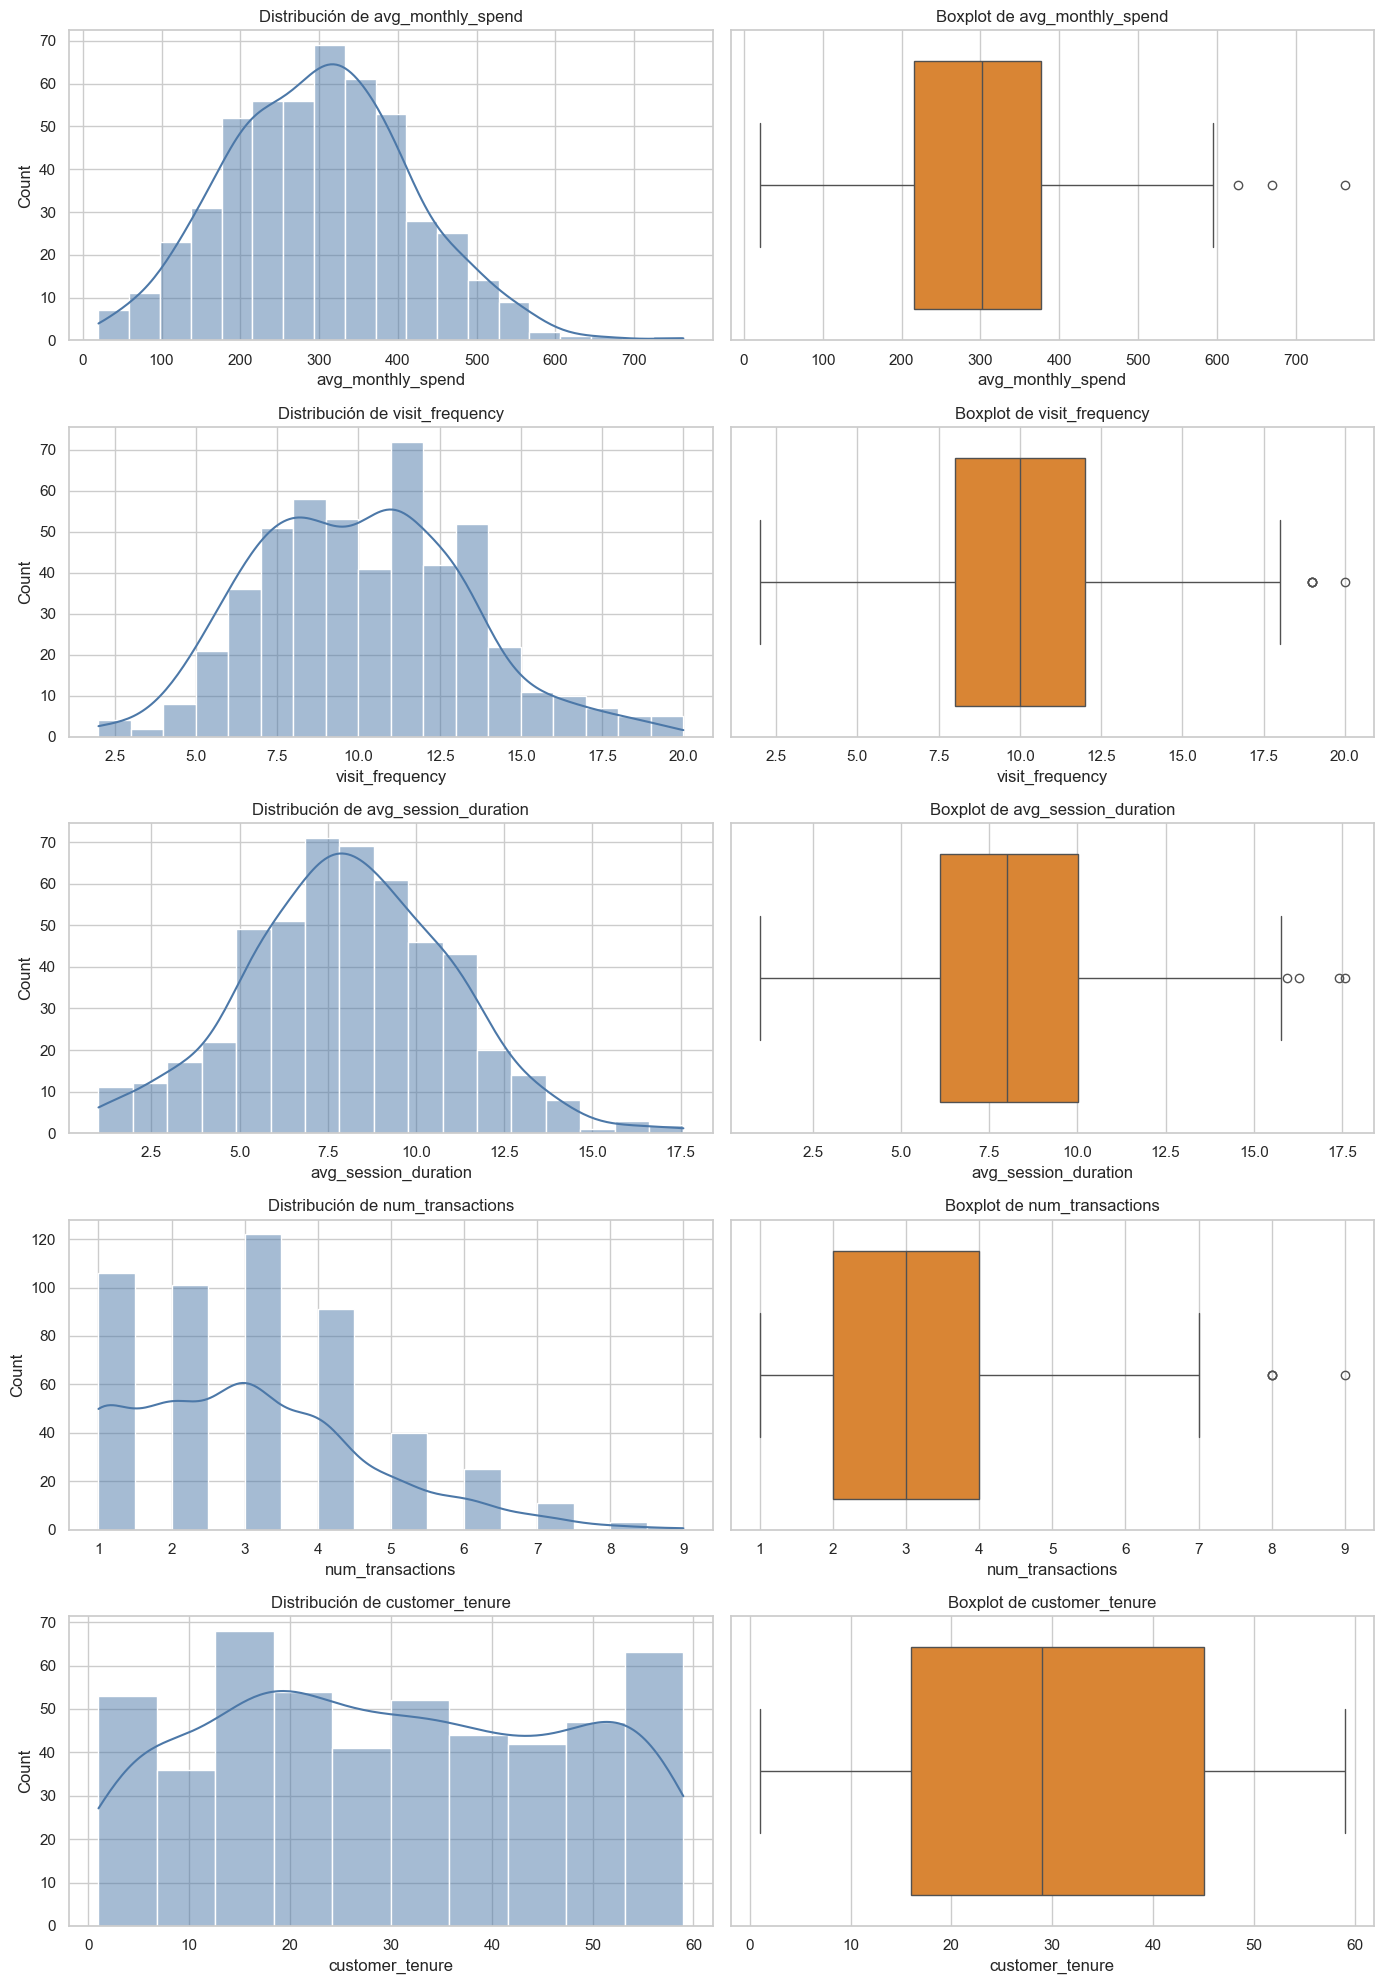

In [9]:
fig, axes = plt.subplots(len(num_cols), 2, figsize=(14, 4 * len(num_cols)))

for i, col in enumerate(num_cols):
    sns.histplot(data=df_limpio, x=col, kde=True, ax=axes[i, 0], color="#4c78a8")
    axes[i, 0].set_title(f"Distribución de {col}")
    axes[i, 0].set_xlabel(col)

    sns.boxplot(data=df_limpio, x=col, ax=axes[i, 1], color="#f58518")
    axes[i, 1].set_title(f"Boxplot de {col}")
    axes[i, 1].set_xlabel(col)

plt.tight_layout()
plt.show()

### Lectura univariada numérica

- `avg_monthly_spend` se concentra alrededor de 300, con algunos clientes de gasto muy alto.
- `visit_frequency` se centra cerca de 10 visitas mensuales.
- `avg_session_duration` se mueve alrededor de 8 minutos por sesión.
- `num_transactions` presenta una mediana de 3 transacciones mensuales.
- `customer_tenure` cubre clientes nuevos y antiguos, aproximadamente entre 1 y 59 meses.

Las escalas son muy diferentes entre gasto, visitas, duracion, transacciones y antigüedad. Esto confirma que en la fase de modelamiento será necesario escalar las variables, especialmente para K-means y DBSCAN.

## 5. Análisis univariado de variables categóricas

In [10]:
for col in cat_cols:
    display(pd.DataFrame({
        "conteo": df_limpio[col].value_counts(),
        "%": (df_limpio[col].value_counts(normalize=True) * 100).round(2)
    }))

,conteo,%
preferred_channel,,
Web,257,51.40
App,163,32.60
Desktop,80,16.00


,conteo,%
country_region,,
Latam,206,41.20
North America,148,29.60
Europe,146,29.20


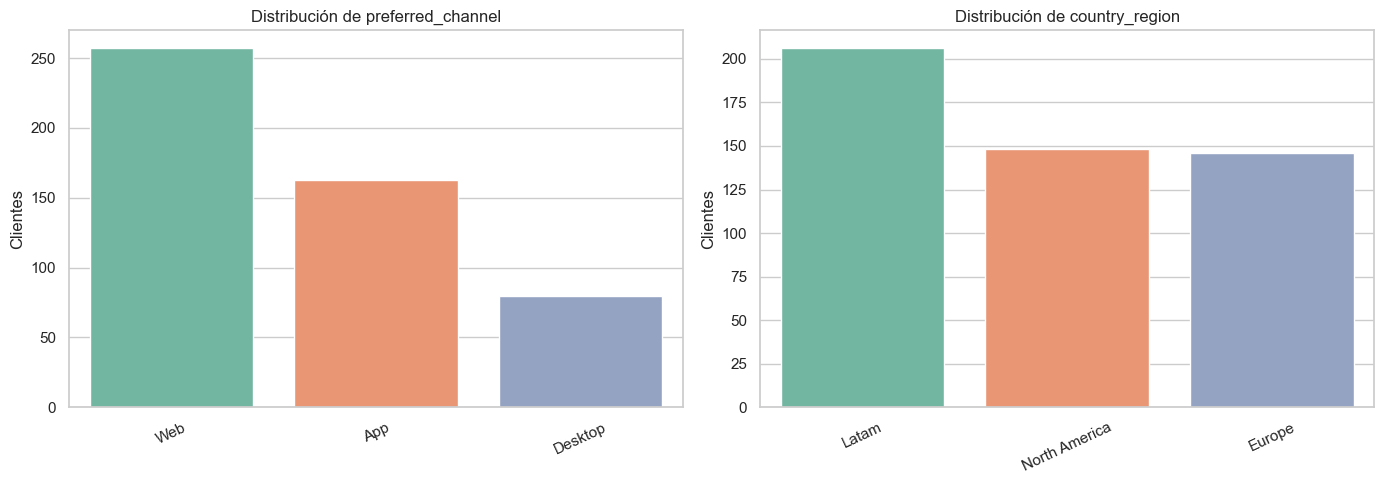

In [11]:
fig, axes = plt.subplots(1, len(cat_cols), figsize=(14, 5))

for ax, col in zip(axes, cat_cols):
    order = df_limpio[col].value_counts().index
    sns.countplot(data=df_limpio, x=col, order=order, ax=ax, palette="Set2")
    ax.set_title(f"Distribución de {col}")
    ax.set_xlabel("")
    ax.set_ylabel("Clientes")
    ax.tick_params(axis="x", rotation=25)

plt.tight_layout()
plt.show()

### Conclusión sobre balance de categorías

`preferred_channel` está dominada por Web, seguida de App y Desktop. `country_region` presenta mayor presencia de Latam, pero North America y Europe tienen tamaños similares. No se recomienda hacer sobremuestreo ni submuestreo porque no hay una clase objetivo y el objetivo es descubrir segmentos reales, no forzar proporciones artificiales. La acción correcta es conservar las categorias y revisar la composición de cada segmento despues del clustering.

## 6. Tratamiento de outliers

Se detectan valores extremos mediante el criterio de rango intercuartílico (IQR). En vez de eliminar clientes, se aplica **capping/winsorizacion** sobre las variables de comportamiento para reducir la influencia de extremos sin perder observaciones.

In [12]:
def resumen_outliers_iqr(data, columns):
    rows = []
    for col in columns:
        q1 = data[col].quantile(0.25)
        q3 = data[col].quantile(0.75)
        iqr = q3 - q1
        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr
        mask = (data[col] < lower) | (data[col] > upper)
        rows.append({
            "variable": col,
            "q1": q1,
            "q3": q3,
            "limite_inferior": lower,
            "limite_superior": upper,
            "outliers": int(mask.sum()),
            "% outliers": round(mask.mean() * 100, 2),
            "min": data[col].min(),
            "max": data[col].max()
        })
    return pd.DataFrame(rows)

outliers_iqr = resumen_outliers_iqr(df_limpio, num_cols)
outliers_iqr.round(2)

,variable,q1,q3,limite_inferior,limite_superior,outliers,% outliers,min,max
0,avg_monthly_spend,215.96,376.42,-24.72,617.10,3,0.60,20.00,762.33
1,visit_frequency,8.00,12.00,2.00,18.00,5,1.00,2.00,20.00
2,avg_session_duration,6.11,10.02,0.24,15.89,4,0.80,1.00,17.58
3,num_transactions,2.00,4.00,-1.00,7.00,4,0.80,1.00,9.00
4,customer_tenure,16.00,45.00,-27.50,88.50,0,0.00,1.00,59.00


In [13]:
def aplicar_capping_iqr(data, columns):
    data_capped = data.copy()
    limites = {}
    for col in columns:
        q1 = data_capped[col].quantile(0.25)
        q3 = data_capped[col].quantile(0.75)
        iqr = q3 - q1
        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr
        limites[col] = (lower, upper)
        data_capped[col] = data_capped[col].clip(lower=lower, upper=upper)
    return data_capped, limites

df_preparado, limites_capping = aplicar_capping_iqr(df_limpio, num_cols)

resumen_post_capping = pd.DataFrame({
    "antes_min": df_limpio[num_cols].min(),
    "antes_max": df_limpio[num_cols].max(),
    "despues_min": df_preparado[num_cols].min(),
    "despues_max": df_preparado[num_cols].max()
})
resumen_post_capping.round(2)

,antes_min,antes_max,despues_min,despues_max
avg_monthly_spend,20.00,762.33,20.00,617.10
visit_frequency,2.00,20.00,2.00,18.00
avg_session_duration,1.00,17.58,1.00,15.89
num_transactions,1.00,9.00,1.00,7.00
customer_tenure,1.00,59.00,1.00,59.00


### Decisión sobre outliers

Se detectan pocos valores extremos en gasto mensual, frecuencia de visita, duracion de sesion y transacciones. Como esos clientes pueden representar comportamientos valiosos, no se eliminan. Se aplica capping para que no dominen la distancia en la etapa de clustering. Esta decisión es especialmente importante para K-means, que es sensible a valores extremos.

## 7. Análisis bivariado

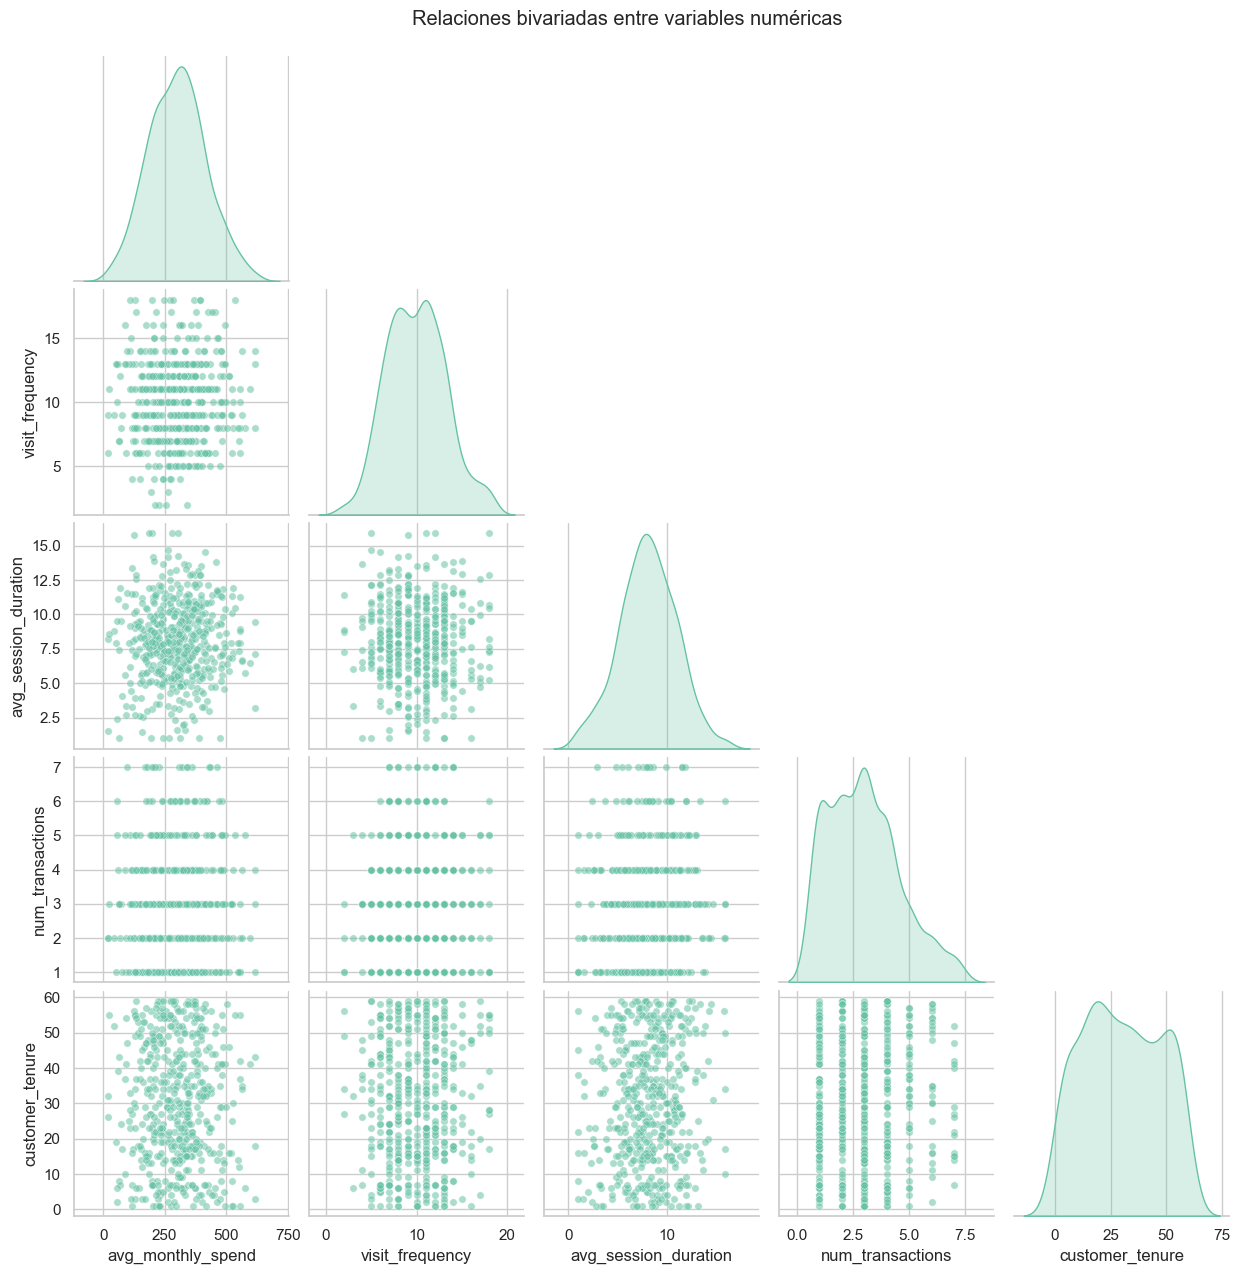

In [14]:
# Relación entre variables numéricas principales
sns.pairplot(
    df_preparado[num_cols],
    diag_kind="kde",
    corner=True,
    plot_kws={"alpha": 0.55, "s": 28}
)
plt.suptitle("Relaciones bivariadas entre variables numéricas", y=1.02)
plt.show()

In [15]:
# Promedios de comportamiento por canal preferido
perfil_canal = df_preparado.groupby("preferred_channel")[num_cols].agg(["mean", "median", "count"]).round(2)
perfil_canal

avg_monthly_spend              visit_frequency               \
                               mean median count            mean median count   
preferred_channel                                                               
App                          314.42 313.62   163           10.14  10.00   163   
Desktop                      289.27 285.32    80            9.30   9.00    80   
Web                          295.54 297.72   257           10.05  10.00   257   

                  avg_session_duration              num_transactions         \
                                  mean median count             mean median   
preferred_channel                                                             
App                               8.00   7.73   163             3.10   3.00   
Desktop                           8.29   8.32    80             2.70   3.00   
Web                               8.04   8.18   257             3.00   3.00   

                        customer_tenure               
                  count            mean median count  
preferred_channel                                     
App                 163           31.64  32.00   163  
Desktop              80           28.20  24.00    80  
Web                 257           29.59  29.00   257

In [16]:
# Promedios de comportamiento por region
perfil_region = df_preparado.groupby("country_region")[num_cols].agg(["mean", "median", "count"]).round(2)
perfil_region

avg_monthly_spend              visit_frequency               \
                            mean median count            mean median count   
country_region                                                               
Europe                    294.64 291.62   146            9.80  10.00   146   
Latam                     301.99 300.62   206            9.86  10.00   206   
North America             304.85 310.01   148           10.25  10.00   148   

               avg_session_duration              num_transactions         \
                               mean median count             mean median   
country_region                                                             
Europe                         8.29   8.10   146             3.08   3.00   
Latam                          7.94   8.01   206             3.12   3.00   
North America                  8.03   7.94   148             2.72   3.00   

                     customer_tenure               
               count            mean median count  
country_region                                     
Europe           146           29.96  29.00   146  
Latam            206           30.09  30.00   206  
North America    148           30.04  29.50   148

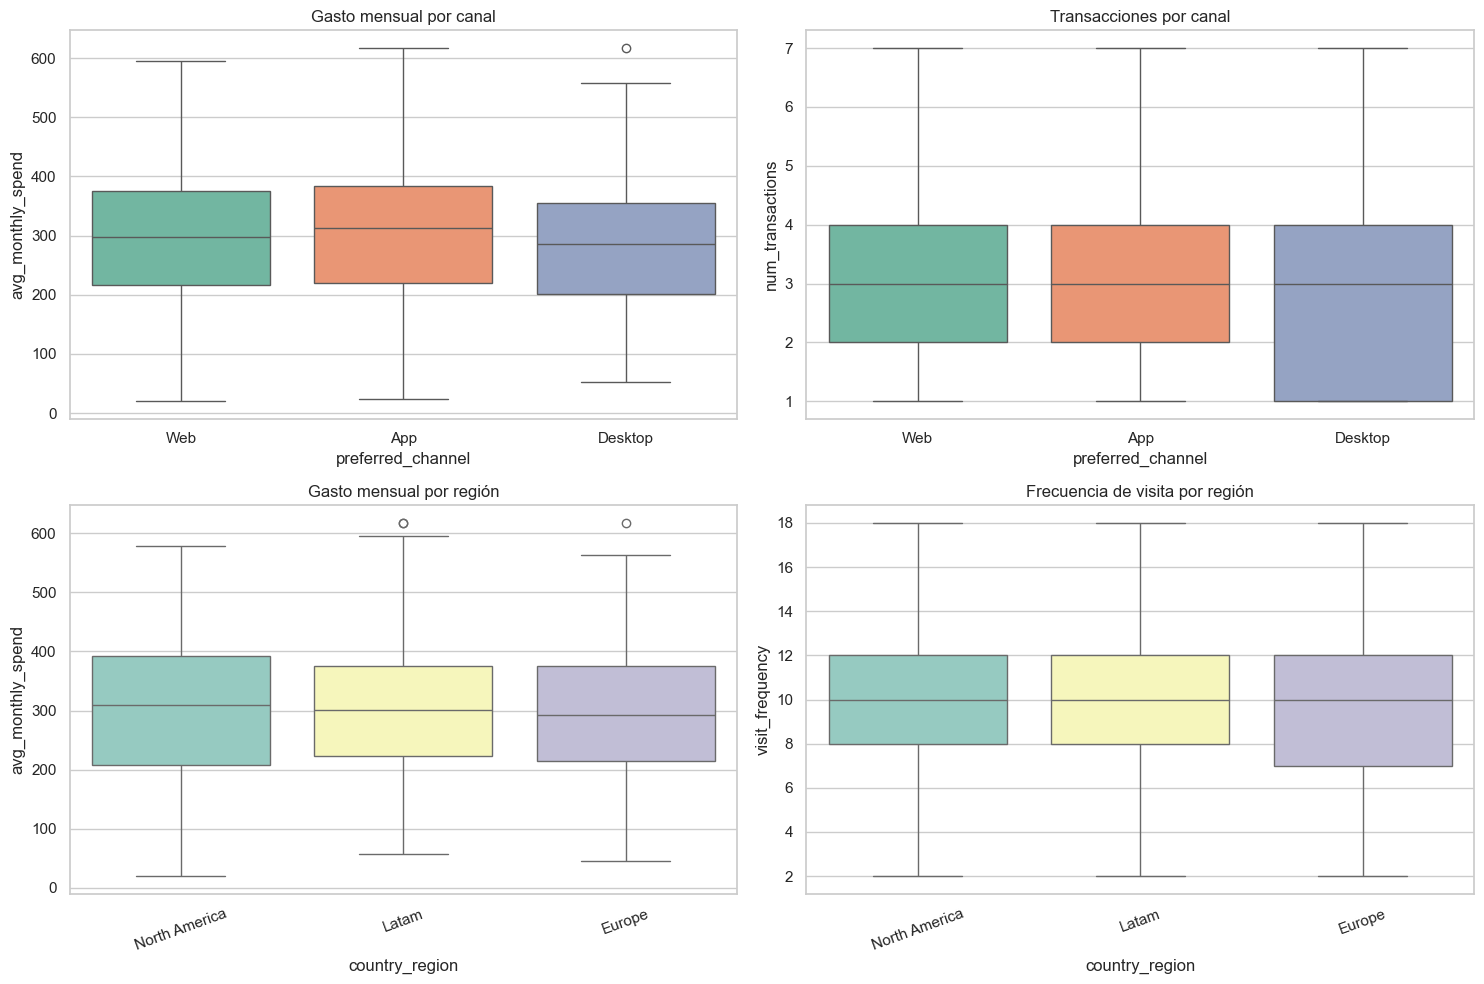

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

sns.boxplot(data=df_preparado, x="preferred_channel", y="avg_monthly_spend", ax=axes[0, 0], palette="Set2")
axes[0, 0].set_title("Gasto mensual por canal")

sns.boxplot(data=df_preparado, x="preferred_channel", y="num_transactions", ax=axes[0, 1], palette="Set2")
axes[0, 1].set_title("Transacciones por canal")

sns.boxplot(data=df_preparado, x="country_region", y="avg_monthly_spend", ax=axes[1, 0], palette="Set3")
axes[1, 0].set_title("Gasto mensual por región")
axes[1, 0].tick_params(axis="x", rotation=20)

sns.boxplot(data=df_preparado, x="country_region", y="visit_frequency", ax=axes[1, 1], palette="Set3")
axes[1, 1].set_title("Frecuencia de visita por región")
axes[1, 1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

In [18]:
# Cruce porcentual entre canal y region.
crosstab_channel_region = pd.crosstab(
    df_preparado["preferred_channel"],
    df_preparado["country_region"],
    normalize="index"
).mul(100).round(2)

crosstab_channel_region

country_region,Europe,Latam,North America
preferred_channel,,,
App,29.45,40.49,30.06
Desktop,33.75,40.00,26.25
Web,27.63,42.02,30.35


### Lectura bivariada

Los promedios por canal y región muestran diferencias moderadas, no rupturas extremas. App presenta un gasto promedio algo mayor que Web y Desktop, mientras que Desktop tiene menor frecuencia de visitas y transacciones. Por región, los niveles de gasto y frecuencia son relativamente cercanos. Esto sugiere que los segmentos no deberían definirse solo por una categoría, sino por la combinación de gasto, actividad, transacciones, antigüedad y canal.

## 8. Matriz de correlación general

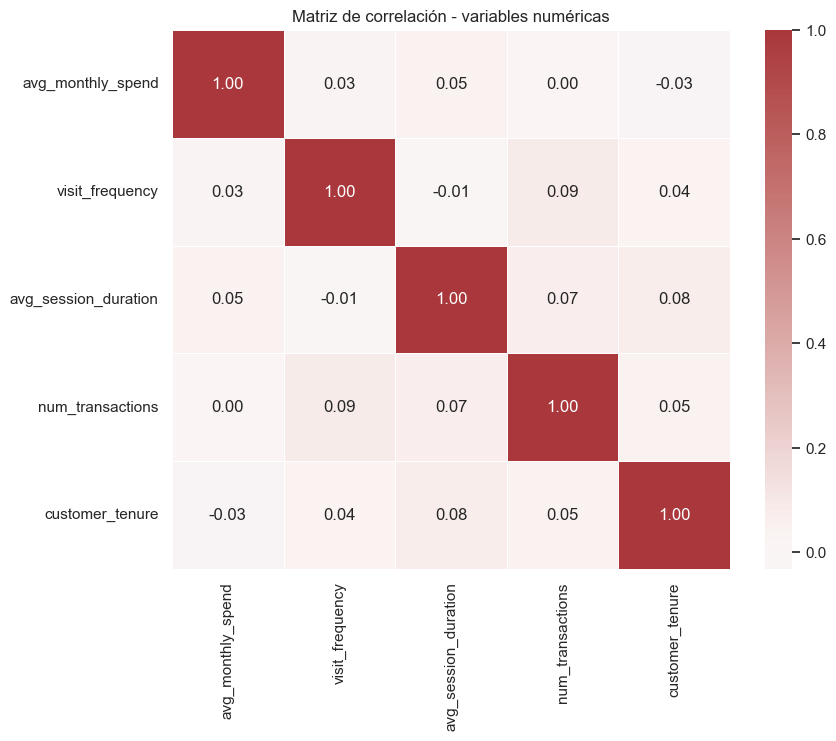

,avg_monthly_spend,visit_frequency,avg_session_duration,num_transactions,customer_tenure
avg_monthly_spend,1.00,0.03,0.05,0.01,-0.03
visit_frequency,0.03,1.00,-0.01,0.09,0.04
avg_session_duration,0.05,-0.01,1.00,0.07,0.08
num_transactions,0.01,0.09,0.07,1.00,0.05
customer_tenure,-0.03,0.04,0.08,0.05,1.00


In [19]:
corr = df_preparado[num_cols].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, cmap="vlag", center=0, fmt=".2f", linewidths=0.5)
plt.title("Matriz de correlación - variables numéricas")
plt.show()

corr.round(3)

### Conclusión de correlación

Las correlaciones lineales entre variables numericas son bajas. No se observa una relacion fuerte que obligue a retirar variables por redundancia. Para la etapa de clustering se pueden conservar todas las variables de comportamiento, siempre excluyendo `customer_id`

## 9. Comprobaciones previas al modelamiento no supervisado

Aunque K-means y DBSCAN no exigen normalidad, si requieren cuidar algunos puntos prácticos:

- Las variables deben representar comportamiento real, por eso se excluye `customer_id`.
- Las variables numéricas deben estar en escalas comparables.
- Las variables categóricas deben codificarse numericamente.
- Los outliers deben revisarse porque afectan distancias y densidades.
- No se balancean clases porque no existe variable objetivo.

In [20]:
checks = {
    "Sin nulos": df_preparado.isna().sum().sum() == 0,
    "Sin duplicados completos": df_preparado.duplicated().sum() == 0,
    "ID unico": df_preparado[id_col].is_unique,
    "ID excluido de features": id_col not in num_cols + cat_cols,
    "Columnas numericas disponibles": set(num_cols).issubset(df_preparado.columns),
    "Columnas categoricas disponibles": set(cat_cols).issubset(df_preparado.columns),
}

pd.Series(checks, name="cumple")

Sin nulos                           True
Sin duplicados completos            True
ID unico                            True
ID excluido de features             True
Columnas numericas disponibles      True
Columnas categoricas disponibles    True
Name: cumple, dtype: bool

## 10. Encoding y escalamiento para la siguiente etapa

Se prepara una matriz de variables lista para aplicar K-means o DBSCAN. Las variables categoricas se transforman con one-hot encoding y todas las variables resultantes se escalan.

In [21]:
# Base de features sin identificador
features_base = df_preparado[num_cols + cat_cols].copy()

# One-hot encoding para variables categóricas.
X_encoded = pd.get_dummies(features_base, columns=cat_cols, drop_first=False, dtype=int)

# Escalamiento de todas las variables codificadas
scaler = StandardScaler()
X_scaled_array = scaler.fit_transform(X_encoded)
X_scaled = pd.DataFrame(X_scaled_array, columns=X_encoded.columns, index=df_preparado.index)

print(f"Matriz codificada: {X_encoded.shape}")
print(f"Matriz escalada: {X_scaled.shape}")
X_scaled.head()

Matriz codificada: (500, 11)
Matriz escalada: (500, 11)


,avg_monthly_spend,visit_frequency,avg_session_duration,num_transactions,customer_tenure,preferred_channel_App,preferred_channel_Desktop,preferred_channel_Web,country_region_Europe,country_region_Latam,country_region_North America
0,0.51,0.32,-0.26,0.01,1.62,-0.70,-0.44,0.97,-0.64,-0.84,1.54
1,-0.15,0.32,0.36,1.91,0.29,-0.70,-0.44,0.97,-0.64,1.19,-0.65
2,0.67,-1.54,0.93,1.28,-0.70,1.44,-0.44,-1.03,1.56,-0.84,-0.65
3,1.58,-0.92,-0.86,1.91,-1.10,1.44,-0.44,-1.03,-0.64,1.19,-0.65
4,-0.25,-0.92,1.53,-1.26,1.39,-0.70,-0.44,0.97,-0.64,1.19,-0.65


In [22]:
# Validación del escalamiento: medias cercanas a 0 y desviaciones estándar cercanas a 1.
validacion_escalamiento = pd.DataFrame({
    "media": X_scaled.mean().round(4),
    "desv_std": X_scaled.std(ddof=0).round(4)
})
validacion_escalamiento

,media,desv_std
avg_monthly_spend,-0.00,1.00
visit_frequency,-0.00,1.00
avg_session_duration,-0.00,1.00
num_transactions,-0.00,1.00
customer_tenure,-0.00,1.00
preferred_channel_App,-0.00,1.00
preferred_channel_Desktop,0.00,1.00
preferred_channel_Web,-0.00,1.00
country_region_Europe,-0.00,1.00
country_region_Latam,0.00,1.00


## 11. Conclusiones y recomendaciones preliminares accionables

1. La base está limpia: no hay nulos, duplicados ni IDs repetidos. Se puede avanzar a modelamiento sin imputaciones.
2. Existen pocos outliers, especialmente en gasto, visitas, duración y transacciones. Se recomienda usar la versión con capping (`df_preparado`) para K-means y comparar sensibilidad con la base sin capping si se desea validar robustez.
3. No corresponde hacer balanceo de clases porque el problema es no supervisado. Las diferencias de tamaño en canal y region deben usarse para interpretacion, no para alterar artificialmente la muestra.
4. Las variables numericas tienen escalas muy distintas, por lo que el uso de `X_scaled` será necesario para K-means y DBSCAN.
5. Como las correlaciones son bajas, todas las variables de comportamiento pueden mantenerse para descubrir segmentos.

### Recomendación accionable previa al clustering

Con base en el EDA, la empresa debería preparar campañas diferenciadas alrededor de tres ejes de comportamiento que luego serán validados con K-means o DBSCAN: **valor económico** (`avg_monthly_spend` y `num_transactions`), **engagement digital** (`visit_frequency` y `avg_session_duration`) y **madurez del cliente** (`customer_tenure`). En la siguiente etapa, los clusters deberan perfilarse con estos ejes para diseñar acciones como retención de clientes antiguos con baja actividad, beneficios para clientes de alto gasto y campañas de activacion para clientes con muchas visitas pero pocas transacciones.

## 12. Elección del modelo de segmentación

Se elige K-means como modelo principal.
Razón: El dataset tiene variables conductuales continuas y discretas, ya tratadas por outliers y escaladas, lo que encaja bien con un método basado en distancias. Además se busca una segmentación accionable para campañas, por lo que conviene obtener grupos compactos, comparables y fáciles de perfilar.

DBSCAN se revisa como contraste, pero no se selecciona porque en este dataset tiende a formar un solo grupo grande o a clasificar demasiados registros como ruido según el valor de `eps`. Eso indica que no hay estructuras de densidad suficientemente separadas para que DBSCAN sea la mejor opción de negocio.

Para evitar que el clustering se limite a separar por canal o región, el modelo se entrena con variables numéricas de comportamiento. Las variables categóricas se usan después para perfilar cada segmento.

In [ ]:
# Matriz final para modelamiento: solo comportamiento numérico
# Canal y región se reservan para interpretar los segmentos
X_model = df_preparado[num_cols].copy()

scaler_model = StandardScaler()
X_model_scaled = pd.DataFrame(
    scaler_model.fit_transform(X_model),
    columns=num_cols,
    index=df_preparado.index
)

X_model_scaled.head()

,avg_monthly_spend,visit_frequency,avg_session_duration,num_transactions,customer_tenure
0,0.51,0.32,-0.26,0.01,1.62
1,-0.15,0.32,0.36,1.91,0.29
2,0.67,-1.54,0.93,1.28,-0.70
3,1.58,-0.92,-0.86,1.91,-1.10
4,-0.25,-0.92,1.53,-1.26,1.39


## 13. Revisión breve de DBSCAN

Se prueba una grilla simple de `eps` para confirmar si existen grupos densos claramente separados. Esta revisión no busca optimizar DBSCAN en profundidad, sino validar si tiene sentido frente al objetivo del caso.

In [24]:
dbscan_rows = []

for eps in [0.8, 1.0, 1.2, 1.4, 1.6, 1.8, 2.0, 2.2]:
    dbscan = DBSCAN(eps=eps, min_samples=10)
    labels = dbscan.fit_predict(X_model_scaled)
    n_clusters = len(set(labels) - {-1})
    noise_pct = (labels == -1).mean() * 100

    silhouette_non_noise = np.nan
    non_noise_mask = labels != -1
    if n_clusters >= 2 and non_noise_mask.sum() > n_clusters:
        silhouette_non_noise = silhouette_score(
            X_model_scaled.loc[non_noise_mask],
            labels[non_noise_mask]
        )

    dbscan_rows.append({
        "eps": eps,
        "clusters": n_clusters,
        "% ruido": noise_pct,
        "silhouette_sin_ruido": silhouette_non_noise
    })

resultados_dbscan = pd.DataFrame(dbscan_rows)
resultados_dbscan.round(4)

,eps,clusters,% ruido,silhouette_sin_ruido
0,0.80,0,100.00,NaN
1,1.00,1,64.40,NaN
2,1.20,1,23.60,NaN
3,1.40,1,9.40,NaN
4,1.60,1,2.20,NaN
5,1.80,1,0.40,NaN
6,2.00,1,0.20,NaN
7,2.20,1,0.00,NaN


### Decisión sobre DBSCAN

DBSCAN no se utiliza como modelo final porque no identifica varios grupos estables: con `eps` bajos domina el ruido y con `eps` más altos casi todos los clientes terminan en un único cluster. Para una estrategia comercial se necesita una segmentación interpretable y operativa, por lo que K-means es una mejor elección en este caso.

## 14. Selección de número de clusters con K-means

Se evalúan valores de `k` entre 2 y 8 usando inercia, silhouette, Davies-Bouldin y Calinski-Harabasz. Como las métricas no siempre apuntan al mismo valor, la decisión final combina desempeño técnico e interpretabilidad de negocio.

In [25]:
kmeans_rows = []

for k in range(2, 9):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=50)
    labels = kmeans.fit_predict(X_model_scaled)

    kmeans_rows.append({
        "k": k,
        "inercia": kmeans.inertia_,
        "silhouette": silhouette_score(X_model_scaled, labels),
        "davies_bouldin": davies_bouldin_score(X_model_scaled, labels),
        "calinski_harabasz": calinski_harabasz_score(X_model_scaled, labels)
    })

resultados_kmeans = pd.DataFrame(kmeans_rows)
resultados_kmeans.round(4)

,k,inercia,silhouette,davies_bouldin,calinski_harabasz
0,2,"2,116.53",0.15,2.24,90.23
1,3,"1,867.26",0.15,1.95,84.21
2,4,"1,671.30",0.15,1.74,81.98
3,5,"1,523.76",0.15,1.61,79.28
4,6,"1,395.45",0.16,1.50,78.20
5,7,"1,308.33",0.16,1.49,74.84
6,8,"1,235.98",0.16,1.49,71.88


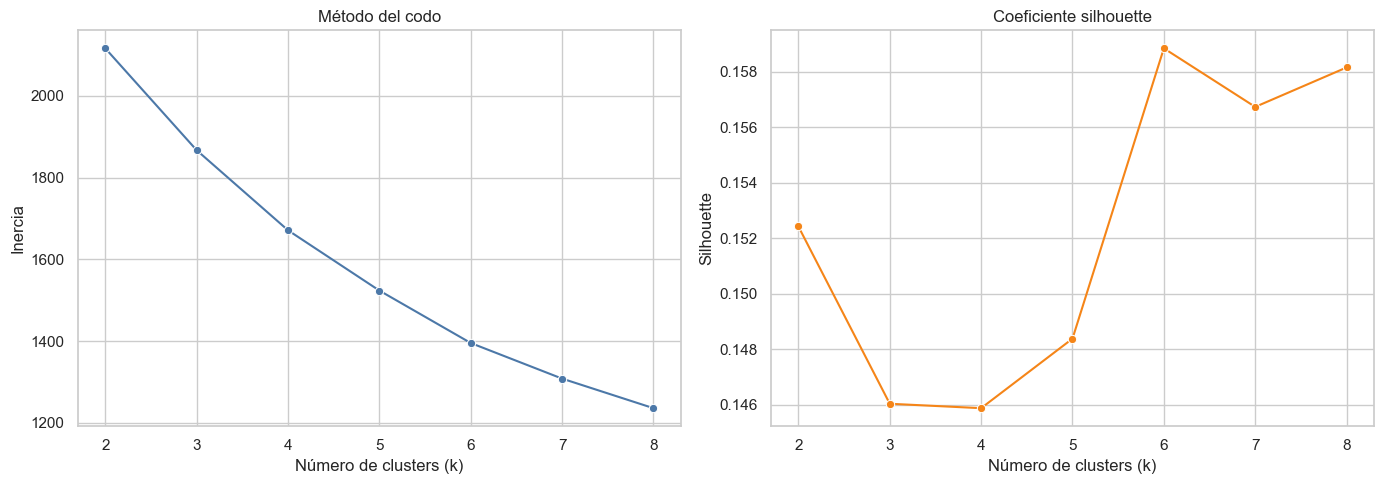

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.lineplot(data=resultados_kmeans, x="k", y="inercia", marker="o", ax=axes[0], color="#4c78a8")
axes[0].set_title("Método del codo")
axes[0].set_xlabel("Número de clusters (k)")
axes[0].set_ylabel("Inercia")

sns.lineplot(data=resultados_kmeans, x="k", y="silhouette", marker="o", ax=axes[1], color="#f58518")
axes[1].set_title("Coeficiente silhouette")
axes[1].set_xlabel("Número de clusters (k)")
axes[1].set_ylabel("Silhouette")

plt.tight_layout()
plt.show()

### Elección de k

Se selecciona **k = 4**. Aunque los valores de silhouette son moderados, cuatro clusters ofrecen una lectura comercial clara y tamaños suficientemente balanceados. Valores más altos dividen la base en grupos más pequeños, pero agregan complejidad sin una mejora contundente para la toma de decisiones.

## 15. Entrenamiento del modelo K-means final

Se entrena K-means con 4 segmentos usando las variables conductuales escaladas. Luego se agregan las etiquetas al dataset para perfilar cada grupo.

In [27]:
K_FINAL = 4

modelo_kmeans = KMeans(n_clusters=K_FINAL, random_state=42, n_init=50)
labels_kmeans = modelo_kmeans.fit_predict(X_model_scaled)

df_modelado = df_preparado.copy()
df_modelado["segmento"] = labels_kmeans

tamano_segmentos = pd.DataFrame({
    "clientes": df_modelado["segmento"].value_counts().sort_index(),
    "% base": (df_modelado["segmento"].value_counts(normalize=True).sort_index() * 100).round(2)
})

tamano_segmentos

,clientes,% base
segmento,,
0,114,22.80
1,125,25.00
2,134,26.80
3,127,25.40


In [28]:
metricas_modelo_final = pd.DataFrame({
    "métrica": ["silhouette", "davies_bouldin", "calinski_harabasz", "inercia"],
    "valor": [
        silhouette_score(X_model_scaled, labels_kmeans),
        davies_bouldin_score(X_model_scaled, labels_kmeans),
        calinski_harabasz_score(X_model_scaled, labels_kmeans),
        modelo_kmeans.inertia_
    ]
})

metricas_modelo_final.round(4)

,métrica,valor
0,silhouette,0.15
1,davies_bouldin,1.74
2,calinski_harabasz,81.98
3,inercia,"1,671.30"


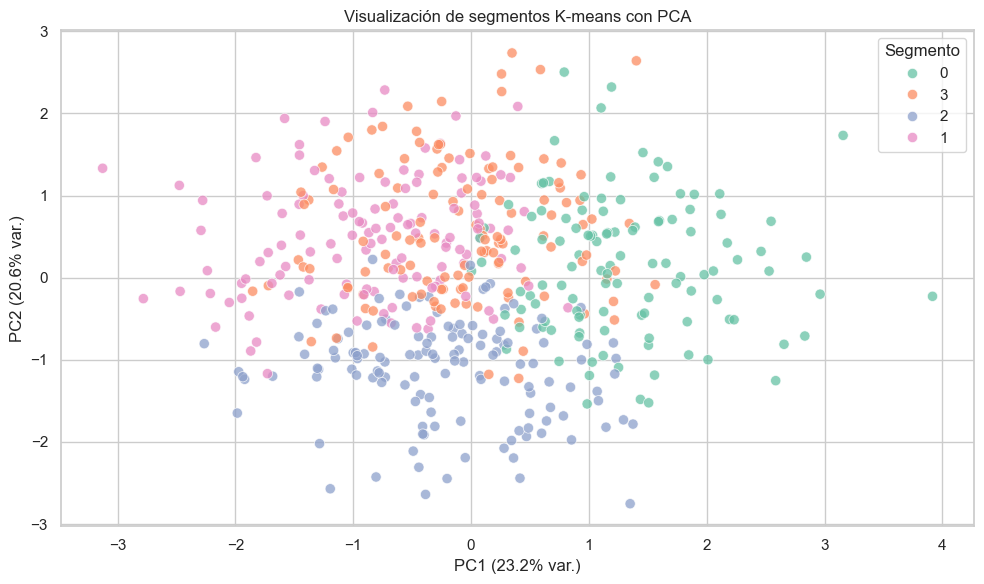

In [29]:
# Visualización 2D con PCA solo para interpretación gráfica.
pca = PCA(n_components=2, random_state=42)
componentes_pca = pca.fit_transform(X_model_scaled)

df_pca = pd.DataFrame(componentes_pca, columns=["PC1", "PC2"])
df_pca["segmento"] = df_modelado["segmento"].astype(str)

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_pca, x="PC1", y="PC2", hue="segmento", palette="Set2", alpha=0.75, s=55)
plt.title("Visualización de segmentos K-means con PCA")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0] * 100:.1f}% var.)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1] * 100:.1f}% var.)")
plt.legend(title="Segmento")
plt.tight_layout()
plt.show()

## 16. Perfilamiento de segmentos

El valor del clustering está en interpretar qué representa cada grupo. Se comparan las medias y medianas de comportamiento, además de la distribución de canal y región dentro de cada segmento.

In [30]:
perfil_numerico_media = df_modelado.groupby("segmento")[num_cols].mean().round(2)
perfil_numerico_mediana = df_modelado.groupby("segmento")[num_cols].median().round(2)

perfil_numerico_media

,avg_monthly_spend,visit_frequency,avg_session_duration,num_transactions,customer_tenure
segmento,,,,,
0,310.99,11.61,8.61,4.81,41.47
1,246.15,11.10,5.49,2.48,19.50
2,257.48,7.63,8.56,2.12,42.36
3,390.73,9.81,9.59,2.76,17.13


In [31]:
perfil_numerico_mediana

,avg_monthly_spend,visit_frequency,avg_session_duration,num_transactions,customer_tenure
segmento,,,,,
0,319.62,11.50,8.48,5.00,44.00
1,243.66,11.00,5.62,2.00,18.00
2,262.65,7.00,8.35,2.00,43.50
3,389.68,10.00,9.52,3.00,16.00


In [32]:
# Comparación contra el promedio general para identificar fortalezas/debilidades relativas.
promedio_general = df_modelado[num_cols].mean()
perfil_relativo = ((perfil_numerico_media - promedio_general) / promedio_general * 100).round(1)
perfil_relativo

,avg_monthly_spend,visit_frequency,avg_session_duration,num_transactions,customer_tenure
segmento,,,,,
0,3.40,16.60,6.70,61.10,38.10
1,-18.10,11.50,-31.90,-16.90,-35.10
2,-14.40,-23.40,6.10,-29.00,41.00
3,29.90,-1.50,18.90,-7.60,-43.00


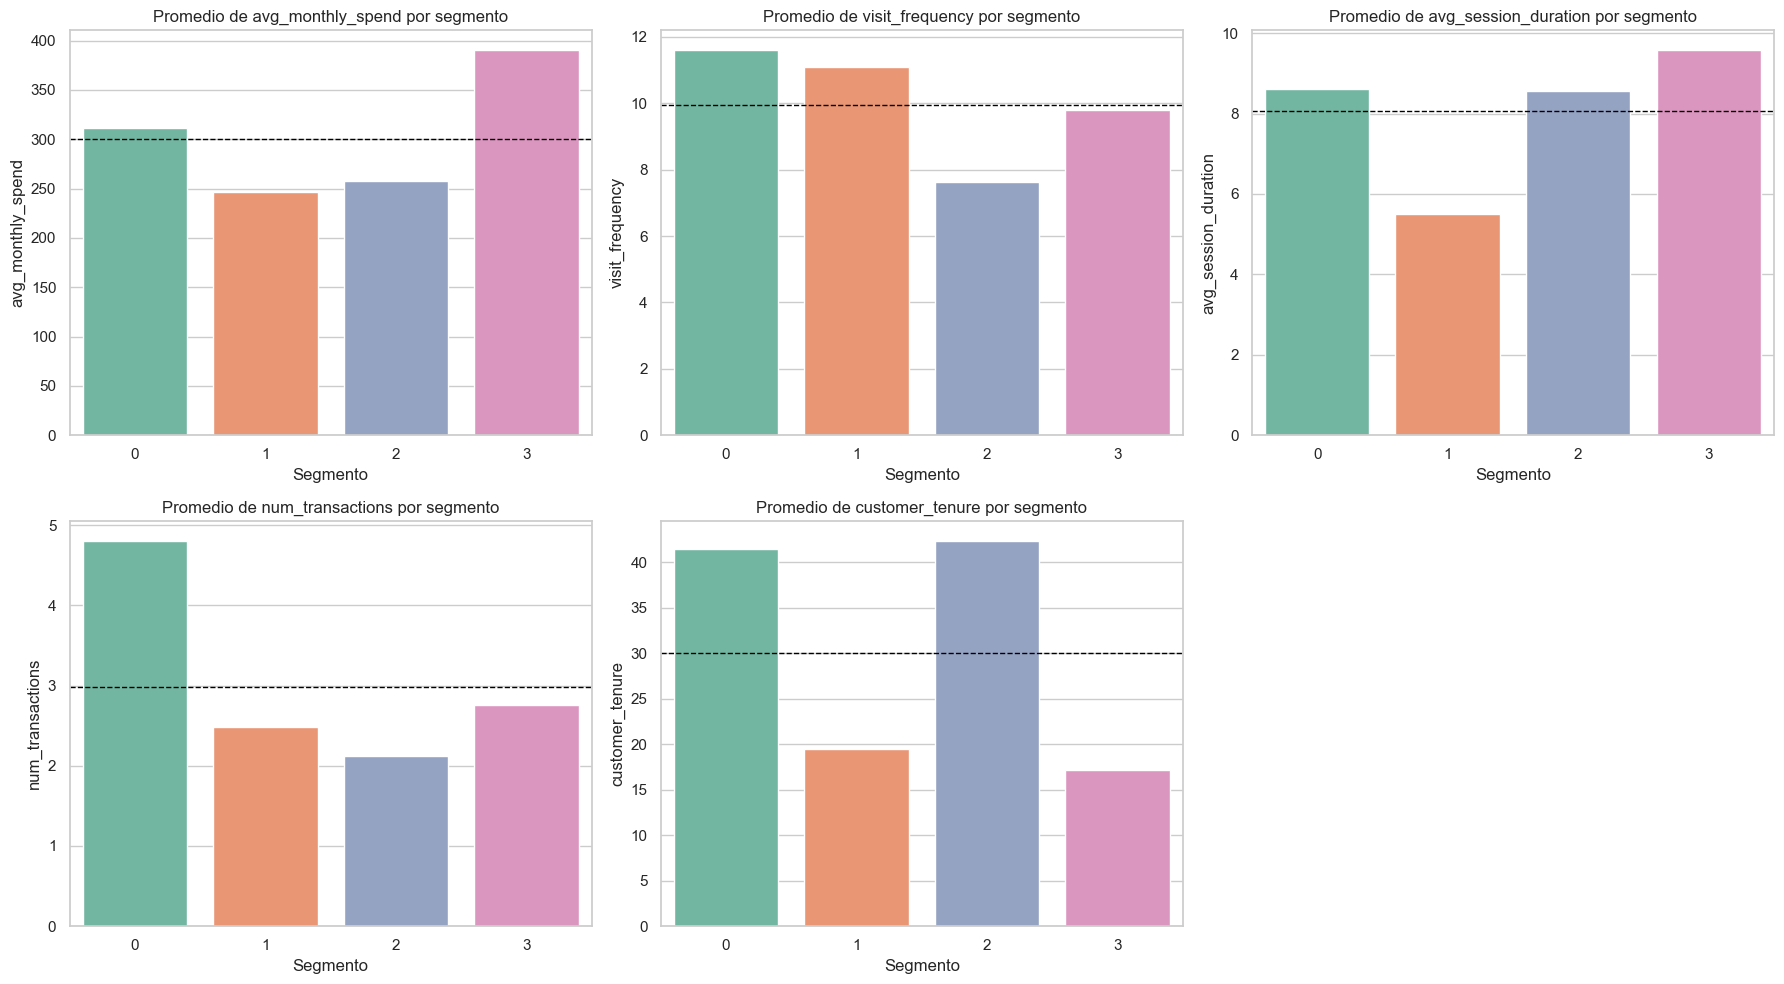

In [33]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.barplot(data=df_modelado, x="segmento", y=col, ax=axes[i], palette="Set2", estimator="mean", errorbar=None)
    axes[i].axhline(df_modelado[col].mean(), color="black", linestyle="--", linewidth=1)
    axes[i].set_title(f"Promedio de {col} por segmento")
    axes[i].set_xlabel("Segmento")
    axes[i].set_ylabel(col)

axes[-1].axis("off")
plt.tight_layout()
plt.show()

In [34]:
distribucion_canal = pd.crosstab(
    df_modelado["segmento"],
    df_modelado["preferred_channel"],
    normalize="index"
).mul(100).round(1)

distribucion_region = pd.crosstab(
    df_modelado["segmento"],
    df_modelado["country_region"],
    normalize="index"
).mul(100).round(1)

distribucion_canal

preferred_channel,App,Desktop,Web
segmento,,,
0,33.30,11.40,55.30
1,28.00,16.80,55.20
2,33.60,17.90,48.50
3,35.40,17.30,47.20


In [35]:
distribucion_region

country_region,Europe,Latam,North America
segmento,,,
0,27.20,49.10,23.70
1,28.80,41.60,29.60
2,32.80,35.80,31.30
3,27.60,39.40,33.10


### Interpretación de segmentos

- **Segmento 0: clientes leales y transaccionales.** Tienen alta antigüedad, alta frecuencia de visita y el mayor número de transacciones. Son buenos candidatos para programas de fidelización, beneficios VIP y campañas de recompra.
- **Segmento 1: visitantes frecuentes de bajo valor reciente.** Visitan bastante, pero tienen menor gasto, menor duración de sesión y pocas transacciones. Requieren activación con ofertas tácticas, recomendaciones personalizadas y mejoras en conversión.
- **Segmento 2: clientes antiguos con baja actividad.** Tienen alta antigüedad, pero baja frecuencia y pocas transacciones. Son un grupo prioritario para campañas de reactivación y prevención de abandono.
- **Segmento 3: clientes de alto gasto y menor antigüedad.** Presentan el mayor gasto mensual y sesiones largas, aunque todavía no tienen alta antigüedad ni muchas transacciones. Conviene acelerar su retención temprana y estimular compras recurrentes.

## 17. Recomendaciones accionables por segmento

| Segmento | Perfil | Acción recomendada | Objetivo de negocio |
|---:|---|---|---|
| 0 | Leales y transaccionales | Programa de fidelización, beneficios por recurrencia, bundles y preventa | Mantener valor y aumentar ticket promedio |
| 1 | Frecuentes pero de bajo gasto | Cupones limitados, remarketing, recomendaciones de productos y optimización de checkout | Convertir visitas en compras |
| 2 | Antiguos con baja actividad | Campañas win-back, mensajes de nostalgia, ofertas de retorno y encuestas de fricción | Reducir abandono y recuperar recurrencia |
| 3 | Alto gasto reciente | Onboarding premium, membresía, cross-selling y beneficios por segunda compra | Retener clientes valiosos temprano |

Las campañas deben personalizarse usando el canal preferido de cada cliente. Como Web es el canal más frecuente, puede ser el eje principal de despliegue, pero App y Desktop deben mantenerse como canales de personalización según preferencia individual.

## 18. Matriz de priorización de negocio

Para priorizar acciones se construye una matriz que combina tamaño del segmento, valor actual, nivel de actividad, riesgo comercial estimado y acción recomendada.

>Esta matriz no reemplaza una métrica real de rentabilidad o churn, pero agrega una capa ejecutiva útil para decidir dónde invertir primero los esfuerzos de marketing y retención.

In [36]:
# Resumen base para priorización comercial.
resumen_segmentos = df_modelado.groupby("segmento").agg(
    clientes=("customer_id", "count"),
    avg_monthly_spend=("avg_monthly_spend", "mean"),
    visit_frequency=("visit_frequency", "mean"),
    avg_session_duration=("avg_session_duration", "mean"),
    num_transactions=("num_transactions", "mean"),
    customer_tenure=("customer_tenure", "mean")
).round(2)

resumen_segmentos["% base"] = (resumen_segmentos["clientes"] / len(df_modelado) * 100).round(2)
resumen_segmentos = resumen_segmentos[["clientes", "% base"] + num_cols]
resumen_segmentos

,clientes,% base,avg_monthly_spend,visit_frequency,avg_session_duration,num_transactions,customer_tenure
segmento,,,,,,,
0,114,22.80,310.99,11.61,8.61,4.81,41.47
1,125,25.00,246.15,11.10,5.49,2.48,19.50
2,134,26.80,257.48,7.63,8.56,2.12,42.36
3,127,25.40,390.73,9.81,9.59,2.76,17.13


In [37]:
# índices relativos contra el promedio general para facilitar lectura de negocio
promedios_base = df_modelado[num_cols].mean()
indices_relativos = (resumen_segmentos[num_cols] / promedios_base * 100).round(1)
indices_relativos.columns = [f"índice_{col}" for col in indices_relativos.columns]
indices_relativos

,índice_avg_monthly_spend,índice_visit_frequency,índice_avg_session_duration,índice_num_transactions,índice_customer_tenure
segmento,,,,,
0,103.40,116.60,106.70,161.10,138.10
1,81.90,111.50,68.10,83.10,64.90
2,85.60,76.60,106.10,71.00,141.00
3,129.90,98.50,118.90,92.40,57.00


In [38]:
# Matriz accionable. Las etiquetas se asignan según el perfil observado en el clustering final
acciones_segmento = {
    0: {
        "perfil_negocio": "Leales y transaccionales",
        "prioridad": "Media-alta",
        "foco": "Fidelización y aumento de ticket",
        "acción_recomendada": "Beneficios VIP, bundles, puntos por recurrencia y preventa de productos",
        "KPI_principal": "Retención, ticket promedio y frecuencia de recompra"
    },
    1: {
        "perfil_negocio": "Frecuentes de baja conversión",
        "prioridad": "Alta",
        "foco": "Conversión de visitas en compras",
        "acción_recomendada": "Cupones limitados, remarketing, recomendaciones personalizadas y mejora del checkout",
        "KPI_principal": "Tasa de conversión y transacciones por cliente"
    },
    2: {
        "perfil_negocio": "Antiguos con baja actividad",
        "prioridad": "Alta",
        "foco": "Reactivación y prevención de abandono",
        "acción_recomendada": "Campañas win-back, ofertas de retorno, mensajes personalizados y encuesta de fricción",
        "KPI_principal": "Reactivación, recompra y reducción de inactividad"
    },
    3: {
        "perfil_negocio": "Alto gasto reciente",
        "prioridad": "Muy alta",
        "foco": "Retención temprana y cross-selling",
        "acción_recomendada": "Onboarding premium, beneficios por segunda compra, membresía y venta cruzada",
        "KPI_principal": "Retención a 30/60/90 días y segunda compra"
    }
}

matriz_priorizacion = resumen_segmentos.reset_index().copy()
matriz_priorizacion["perfil_negocio"] = matriz_priorizacion["segmento"].map(lambda x: acciones_segmento[x]["perfil_negocio"])
matriz_priorizacion["prioridad"] = matriz_priorizacion["segmento"].map(lambda x: acciones_segmento[x]["prioridad"])
matriz_priorizacion["foco"] = matriz_priorizacion["segmento"].map(lambda x: acciones_segmento[x]["foco"])
matriz_priorizacion["acción_recomendada"] = matriz_priorizacion["segmento"].map(lambda x: acciones_segmento[x]["acción_recomendada"])
matriz_priorizacion["KPI_principal"] = matriz_priorizacion["segmento"].map(lambda x: acciones_segmento[x]["KPI_principal"])

columnas_matriz = [
    "segmento", "perfil_negocio", "clientes", "% base", "prioridad", "foco",
    "avg_monthly_spend", "visit_frequency", "num_transactions", "customer_tenure",
    "acción_recomendada", "KPI_principal"
]

matriz_priorizacion[columnas_matriz]

,segmento,perfil_negocio,clientes,% base,prioridad,foco,avg_monthly_spend,visit_frequency,num_transactions,customer_tenure,acción_recomendada,KPI_principal
0,0,Leales y transaccionales,114,22.80,Media-alta,Fidelización y aumento de ticket,310.99,11.61,4.81,41.47,"Beneficios VIP, bundles, puntos por recurrenci...","Retención, ticket promedio y frecuencia de rec..."
1,1,Frecuentes de baja conversión,125,25.00,Alta,Conversión de visitas en compras,246.15,11.10,2.48,19.50,"Cupones limitados, remarketing, recomendacione...",Tasa de conversión y transacciones por cliente
2,2,Antiguos con baja actividad,134,26.80,Alta,Reactivación y prevención de abandono,257.48,7.63,2.12,42.36,"Campañas win-back, ofertas de retorno, mensaje...","Reactivación, recompra y reducción de inactividad"
3,3,Alto gasto reciente,127,25.40,Muy alta,Retención temprana y cross-selling,390.73,9.81,2.76,17.13,"Onboarding premium, beneficios por segunda com...",Retención a 30/60/90 días y segunda compra


### Interpretación de la matriz

La prioridad más alta corresponde al **segmento 3**, porque combina el mayor gasto mensual con baja antigüedad. Es decir, son clientes valiosos que todavía están en una etapa temprana de relación con la empresa; si no se consolidan rápido, se puede perder valor futuro.

Los **segmentos 1 y 2** también requieren atención alta, pero por razones distintas. El segmento 1 tiene visitas frecuentes, aunque convierte poco; por eso el foco debe ser mejorar conversión. El segmento 2 representa clientes antiguos con baja actividad, por lo que el objetivo debe ser reactivarlos antes de que abandonen por completo.

El **segmento 0** es importante por su recurrencia y transaccionalidad. Su prioridad es media-alta porque no muestra el mismo nivel de urgencia que los grupos en riesgo o en etapa temprana, pero sí debe protegerse con beneficios de fidelización y acciones de aumento de ticket.

In [39]:
# Vista ejecutiva compacta para presentación.
matriz_ejecutiva = matriz_priorizacion[[
    "segmento", "perfil_negocio", "% base", "prioridad", "foco", "acción_recomendada", "KPI_principal"
]].copy()

matriz_ejecutiva

,segmento,perfil_negocio,% base,prioridad,foco,acción_recomendada,KPI_principal
0,0,Leales y transaccionales,22.80,Media-alta,Fidelización y aumento de ticket,"Beneficios VIP, bundles, puntos por recurrenci...","Retención, ticket promedio y frecuencia de rec..."
1,1,Frecuentes de baja conversión,25.00,Alta,Conversión de visitas en compras,"Cupones limitados, remarketing, recomendacione...",Tasa de conversión y transacciones por cliente
2,2,Antiguos con baja actividad,26.80,Alta,Reactivación y prevención de abandono,"Campañas win-back, ofertas de retorno, mensaje...","Reactivación, recompra y reducción de inactividad"
3,3,Alto gasto reciente,25.40,Muy alta,Retención temprana y cross-selling,"Onboarding premium, beneficios por segunda com...",Retención a 30/60/90 días y segunda compra


In [40]:
# Exportable operativo para CRM o marketing automation.
# El archivo incluye la etiqueta de segmento para cada cliente.
df_modelado.to_excel("clientes_segmentados.xlsx", index=False)
matriz_priorizacion.to_excel("matriz_priorizacion_segmentos.xlsx", index=False)

print("Archivos generados:")
print("- clientes_segmentados.xlsx")
print("- matriz_priorizacion_segmentos.xlsx")

Archivos generados:
- clientes_segmentados.xlsx
- matriz_priorizacion_segmentos.xlsx


### Conclusión de negocio:

La recomendación es iniciar con dos frentes simultáneos: **retención temprana del segmento 3** y **reactivación/conversión de los segmentos 1 y 2**. El segmento 0 debe mantenerse con fidelización, pero no necesita una intervención tan urgente como los grupos con mayor oportunidad o riesgo comercial.

## 19. Reporte final

Se construyó una segmentación no supervisada para clientes de e-commerce usando variables de gasto, visitas, duración de sesión, transacciones y antigüedad. Después del EDA se confirmó que la base no tiene nulos ni duplicados, que los outliers son pocos y que no corresponde balancear clases porque no existe variable objetivo. Se aplicó capping a valores extremos y escalamiento para trabajar correctamente con distancias.

El modelo elegido fue **K-means con 4 clusters**. Se eligió sobre DBSCAN porque DBSCAN no encontró grupos densos bien separados: tendía a generar un solo cluster o mucho ruido. K-means, en cambio, produjo segmentos balanceados e interpretables para negocio.

La segmentación final identifica cuatro grupos accionables: clientes leales y transaccionales, visitantes frecuentes de bajo valor, clientes antiguos con baja actividad y clientes de alto gasto reciente. La recomendación principal es diseñar campañas diferenciadas por segmento: fidelización para el segmento 0, conversión para el segmento 1, reactivación para el segmento 2 y retención temprana con cross-selling para el segmento 3. La matriz de priorización refuerza que el segmento 3 debe atenderse primero por su alto valor y baja antigüedad, seguido de los segmentos 1 y 2 por oportunidad de conversión y riesgo de inactividad.

Como siguiente paso operativo, la empresa debería cargar la etiqueta `segmento` en su CRM o plataforma de marketing automation y medir campañas con KPIs por grupo: tasa de conversión, frecuencia de recompra, ticket promedio, retención a 30/60/90 días y retorno incremental por campaña.